# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf).

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms.

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY).

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS:
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [ ]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  6335k      0 --:--:--  0:02:22 --:--:-- 8777k


In [ ]:
!rm SUSY.csv

rm: cannot remove 'SUSY.csv': No such file or directory


In [ ]:
!gunzip SUSY.csv.gz

In [ ]:
ls -lh

The data is provided as a comma separated file.

In [ ]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [ ]:
!ls -lh

total 2.3G
drwxr-xr-x 1 root root 4.0K Mar 23 13:29 sample_data
-rw-r--r-- 1 root root 2.3G Mar 28 03:42 SUSY.csv


We see that we have 5 million datapoints.

In [ ]:
!wc -l SUSY.csv

5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [ ]:
!head -500000 SUSY.csv > SUSY-small.csv

In [ ]:
ls -lh

total 2.5G
drwxr-xr-x 1 root root 4.0K Mar 23 13:29 sample_data/
-rw-r--r-- 1 root root 2.3G Mar 28 03:42 SUSY.csv
-rw-r--r-- 1 root root 228M Mar 28 03:43 SUSY-small.csv


In [ ]:
! wc -l SUSY-small.csv

500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [ ]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [ ]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [ ]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [ ]:
FeatureNames

['M_Delta_R',
 'MET_rel',
 'dPhi_r_b',
 'M_TR_2',
 'S_R',
 'MT2',
 'M_R',
 'axial_MET',
 'R',
 'cos_theta_r1']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [ ]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [ ]:
df

The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [ ]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

In [ ]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

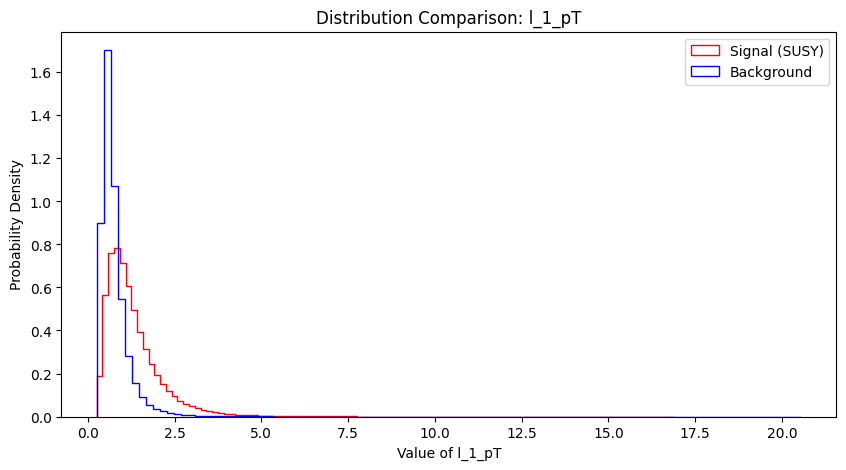

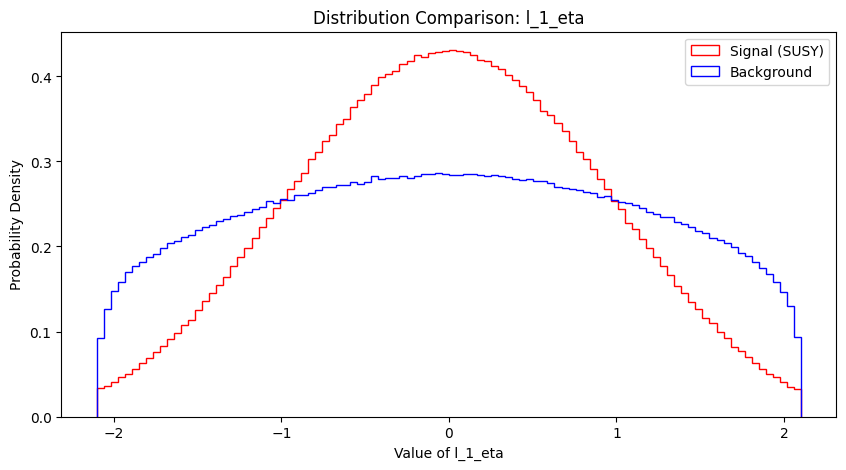

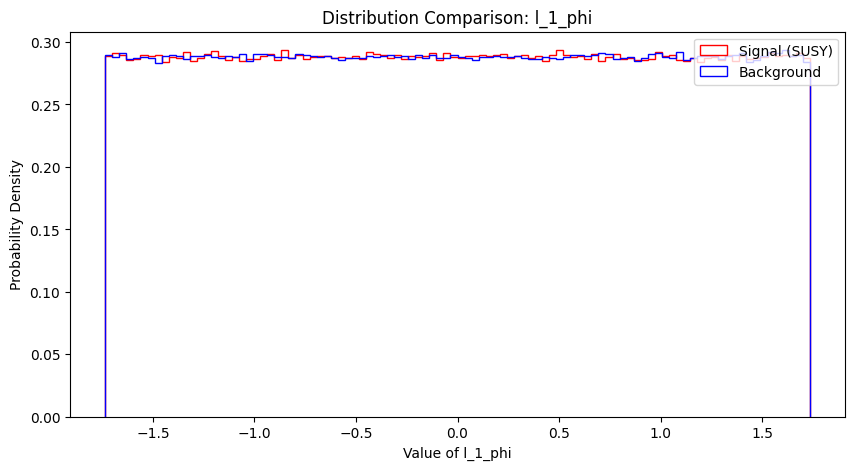

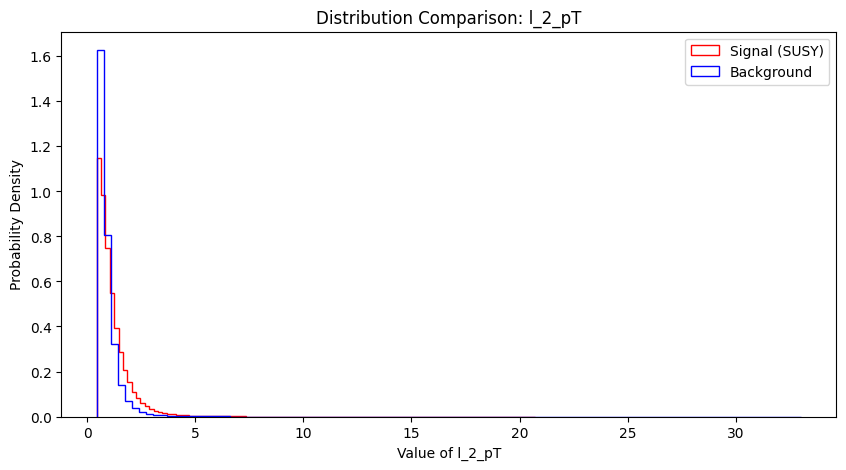

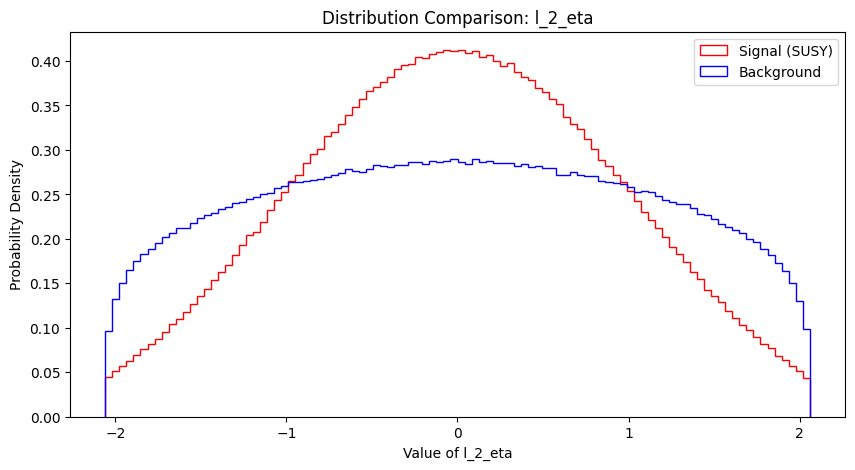

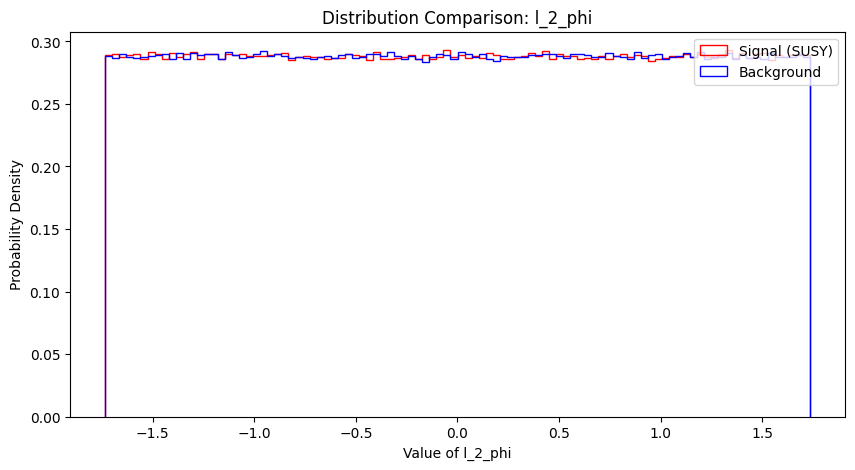

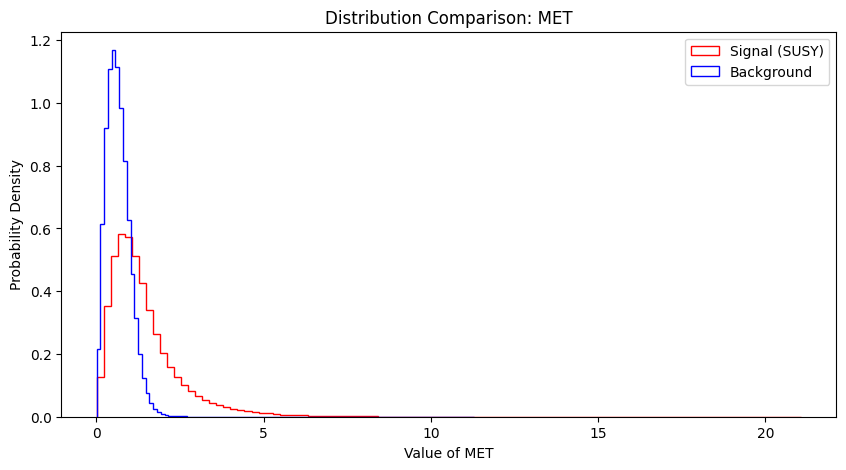

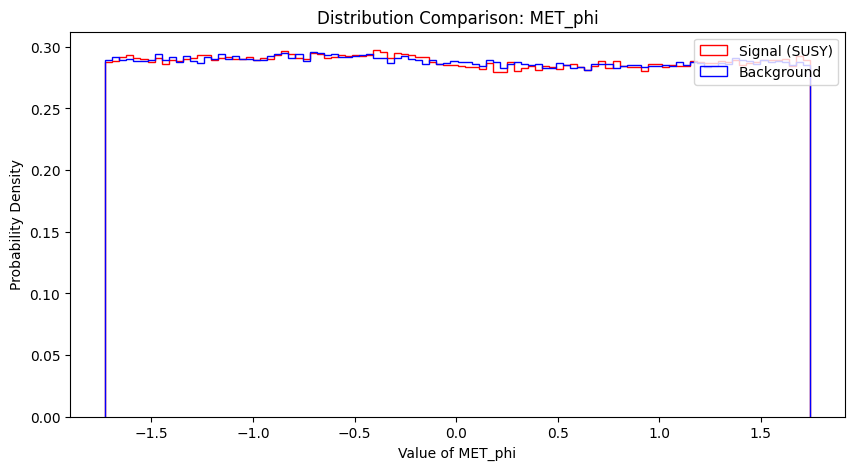

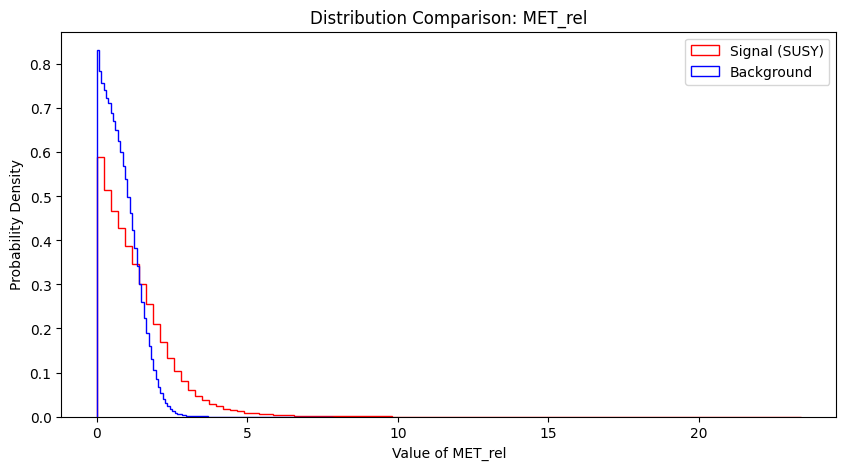

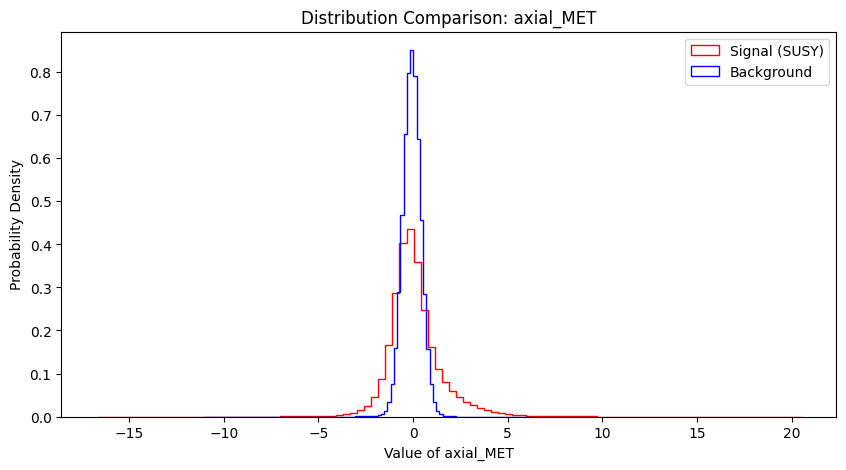

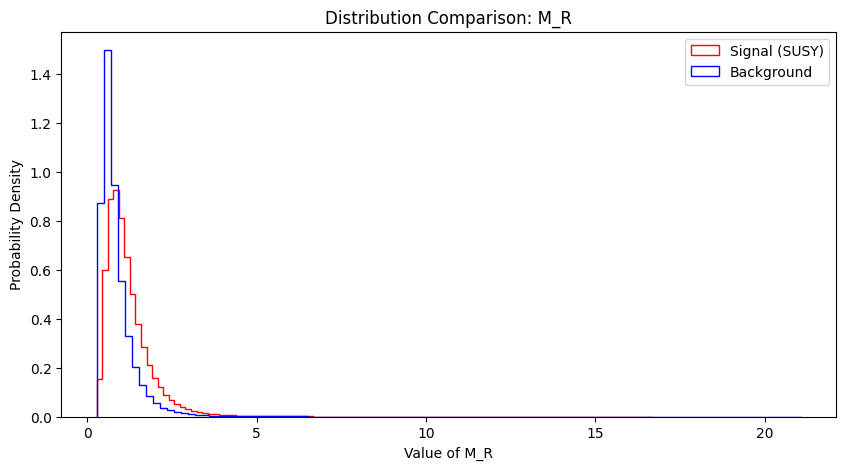

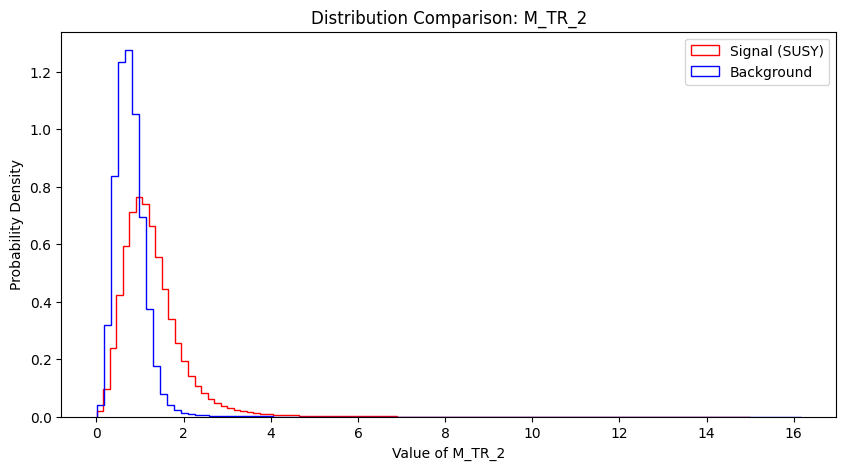

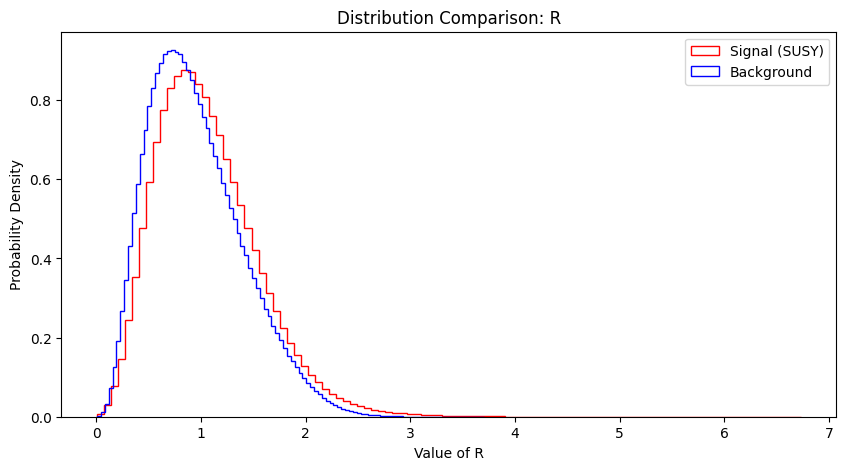

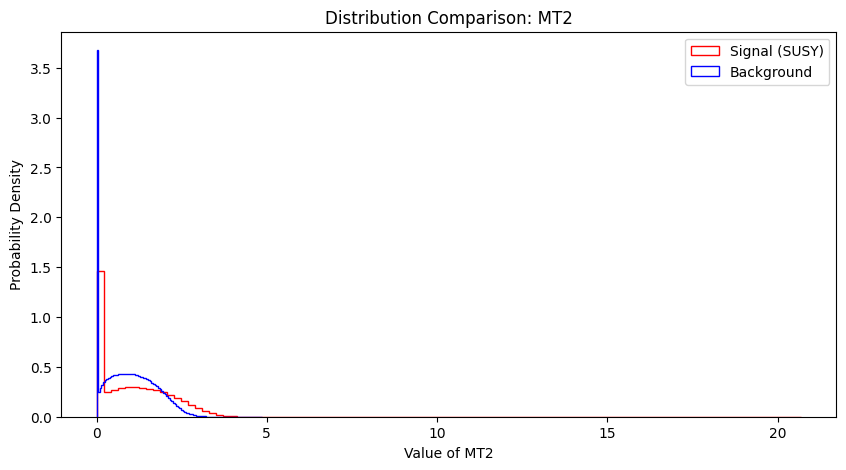

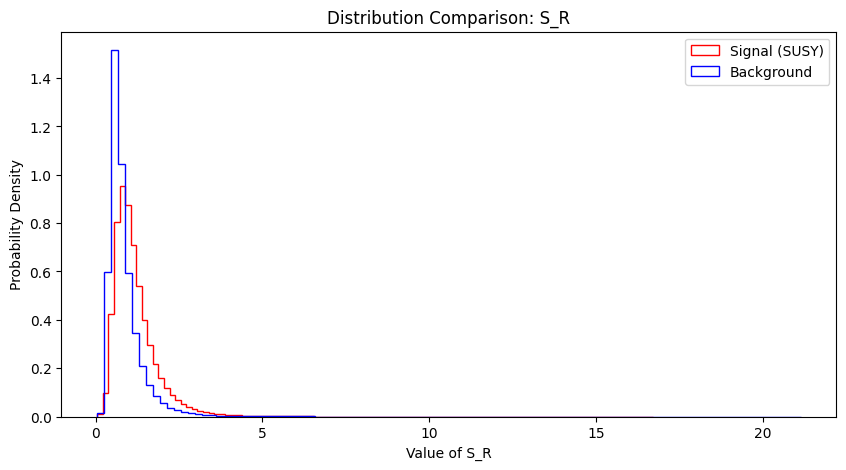

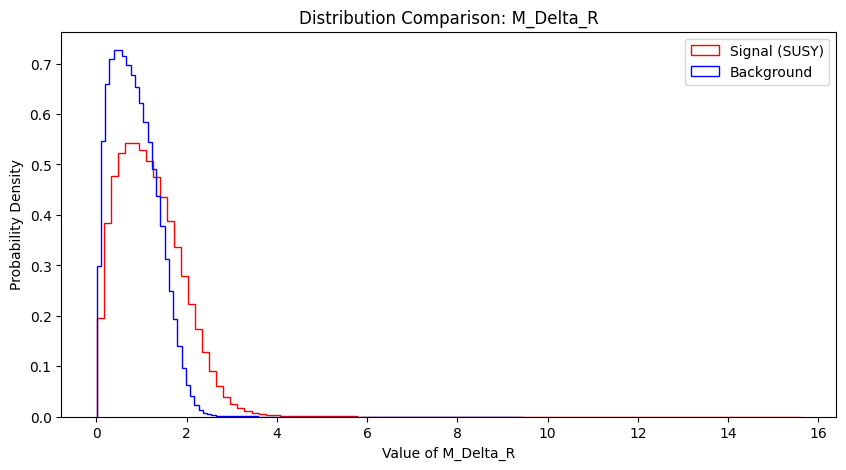

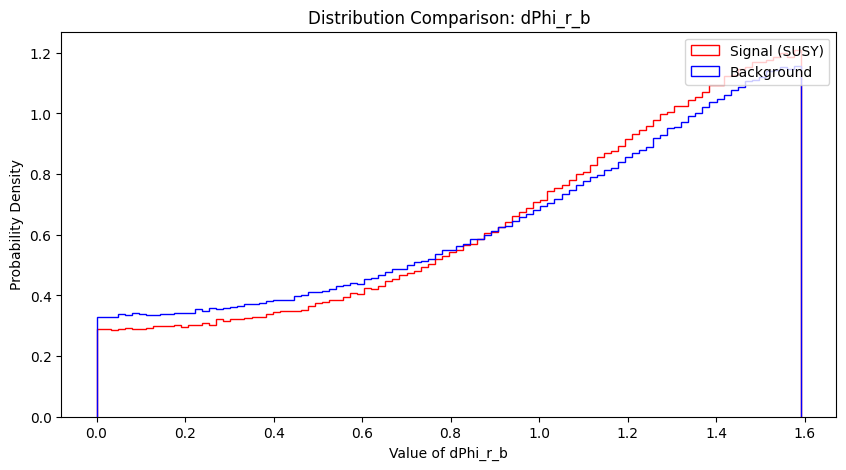

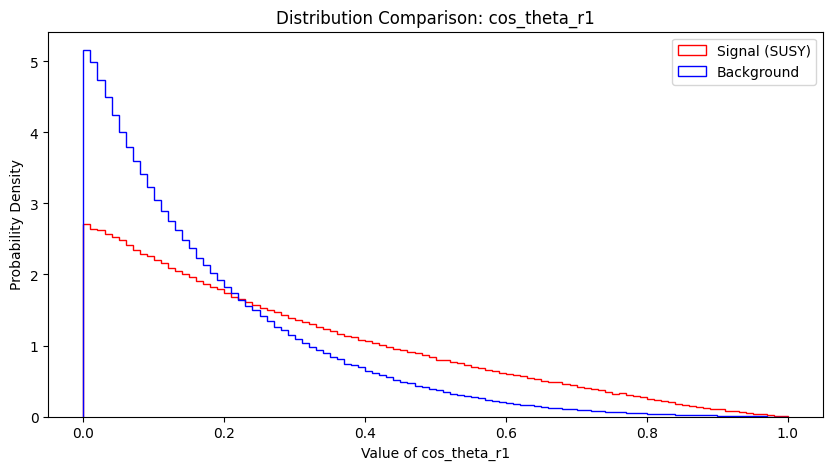

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# configure matplotlib to render plots inline within notebook environments.
%matplotlib inline

# segregate the dataset into signal (SUSY) and background subsets based on the target variable.
df_sig = df[df.signal == 1.0]
df_bkg = df[df.signal == 0.0]

# iterate through the feature variables, omitting the first column.
for var in VarNames[1:]:

    # initialize a new figure with specified dimensions to prevent plot overlap.
    plt.figure(figsize=(10, 5))

    # plot the probability density histogram for the signal events.
    # data is converted to a NumPy array for optimized processing.
    # 'histtype="step"' generates an outlined plot, and 'density=True' normalizes the area
    # to allow for direct shape comparison between unevenly sized datasets.
    plt.hist(np.array(df_sig[var]), bins=100, histtype="step",
             color="red", label="Signal (SUSY)", density=True)

    # overlay the probability density histogram for the background events.
    plt.hist(np.array(df_bkg[var]), bins=100, histtype="step",
             color="blue", label="Background", density=True)

    # apply descriptive titles and axis labels.
    plt.title(f"Distribution Comparison: {var}")
    plt.xlabel(f"Value of {var}")
    plt.ylabel("Probability Density")

    # position the legend in the upper right corner.
    plt.legend(loc='upper right')

    # execute the render command to display the current figure.
    plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

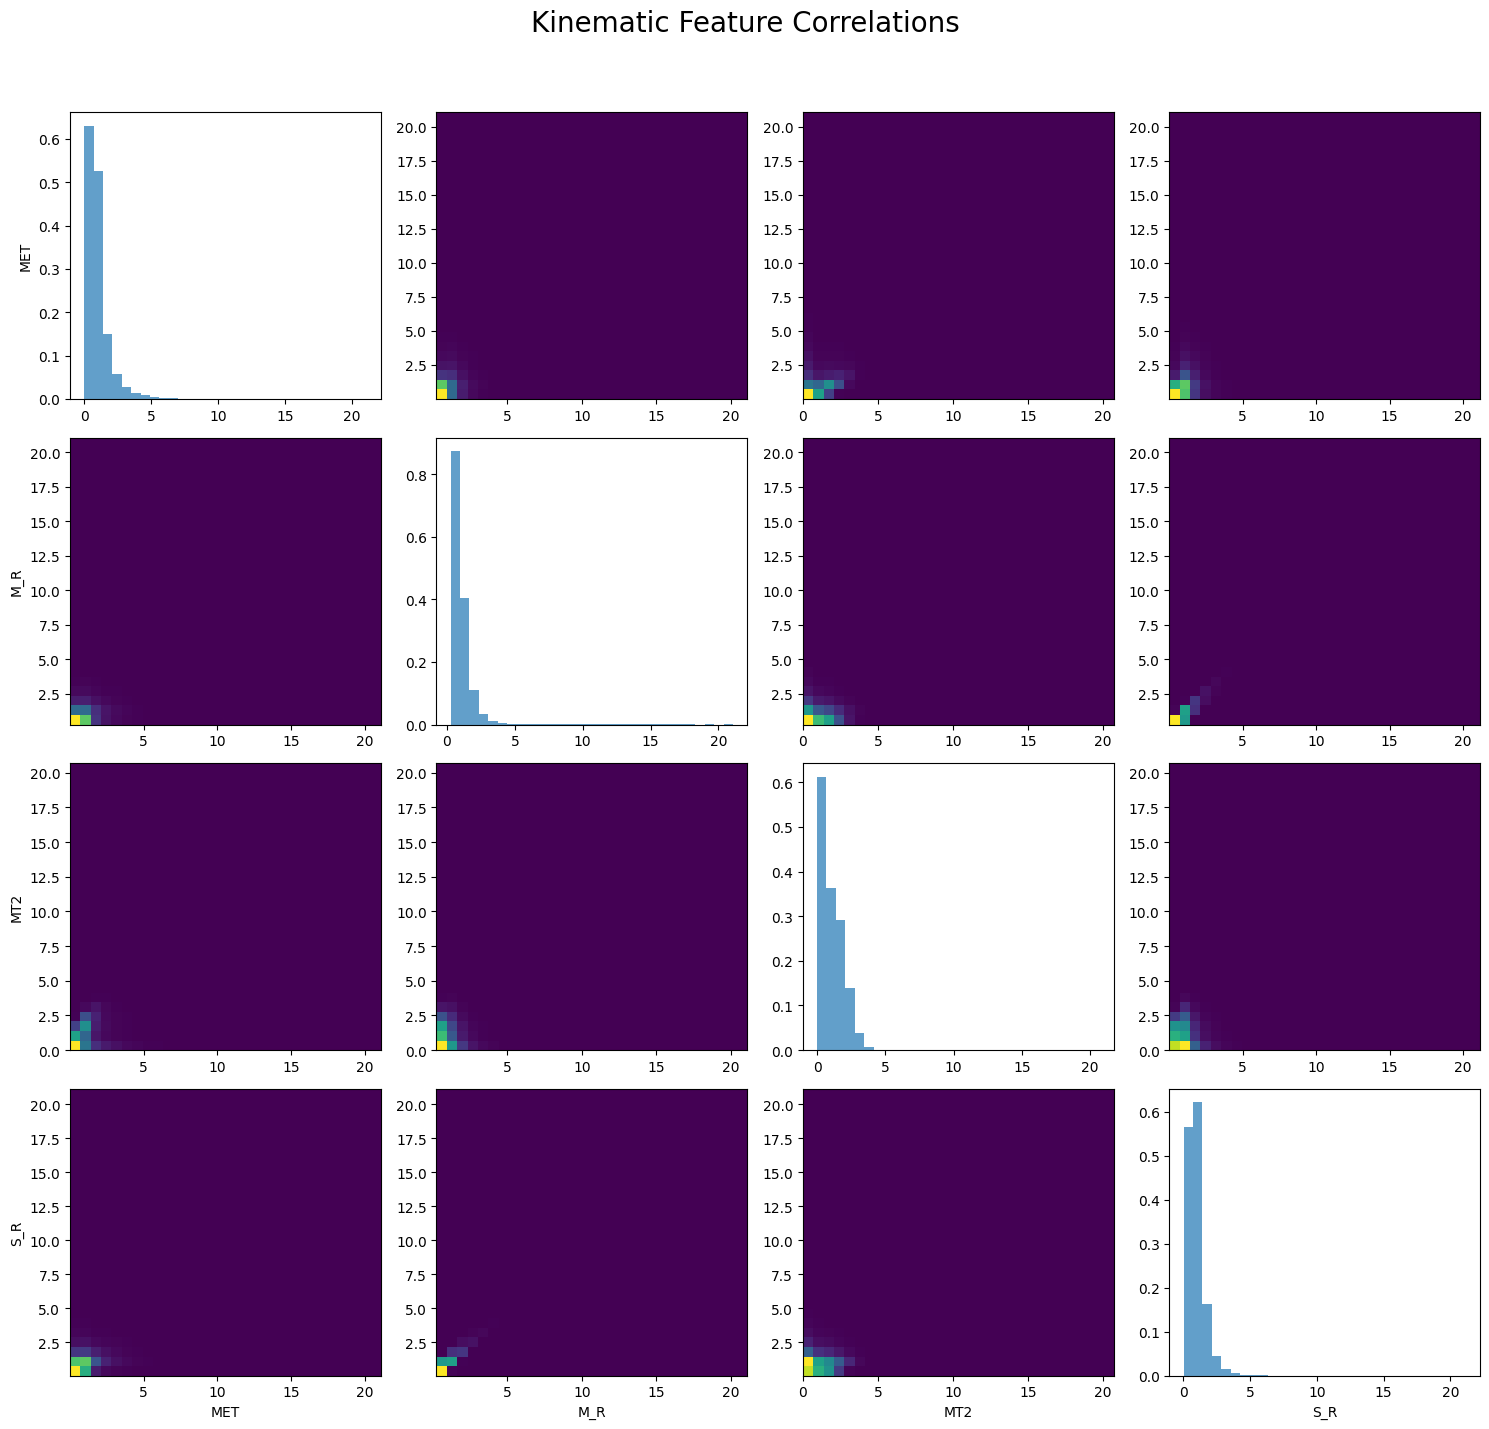

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import tabulate
from IPython.display import HTML, display

def render_bivariate_grid(data_frame, feature_cols, plot_heading):
    # generates a multi-panel figure to analyze bivariate relationships among specified features.
    grid_size = len(feature_cols)
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(15, 15))

    # iterates systematically across the rows and columns of the subplot grid.
    for row_idx, y_feature in enumerate(feature_cols):
        for col_idx, x_feature in enumerate(feature_cols):

            # handles the diagonal axes where the feature intersects with itself.
            if row_idx == col_idx:
                # renders a one-dimensional density histogram representing the feature's marginal distribution.
                axes[row_idx, col_idx].hist(data_frame[y_feature], bins=30, density=True, alpha=0.7)

            else:
                # employs a two-dimensional histogram for off-diagonal relationships to optimize rendering performance.
                # this approach is significantly faster than standard scatter plots when handling large-scale data arrays.
                axes[row_idx, col_idx].hist2d(data_frame[x_feature], data_frame[y_feature], bins=30, cmap='viridis')

            # conditionally applies axis labels only to the outermost plots to maintain a clean aesthetic.
            if row_idx == grid_size - 1:
                axes[row_idx, col_idx].set_xlabel(x_feature)
            if col_idx == 0:
                axes[row_idx, col_idx].set_ylabel(y_feature)

    # applies the overarching title to the figure matrix.
    plt.suptitle(plot_heading, fontsize=20)

    # applies layout constraints to prevent overlapping axes and accommodate the global figure title.
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# defines the specific subset of kinematic variables slated for visual analysis.
selected_metrics = ["MET", "M_R", "MT2", "S_R"]

# executes the rendering function on the designated dataset.
render_bivariate_grid(df, selected_metrics, "Kinematic Feature Correlations")

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate).

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [25]:
from IPython.display import HTML, display
import tabulate

def render_correlation_matrix(dataset, feature_list, table_heading):
    # calculates the pairwise pearson correlation coefficients to evaluate feature redundancy.
    # coefficient magnitudes exceeding 0.8 typically indicate overlapping informational value.
    correlation_matrix = dataset[feature_list].corr()

    # structures the matrix data for html rendering by injecting the row label as the first element.
    formatted_rows = [[feature_list[idx]] + list(row_values) for idx, row_values in enumerate(correlation_matrix.values)]

    # establishes the table headers, incorporating an empty string for the top-left structural cell.
    column_headers = [""] + feature_list

    print(f"\n{table_heading}")

    # generates and displays the html-formatted table, truncating floats to two decimal places for readability.
    html_output = tabulate.tabulate(formatted_rows, headers=column_headers, tablefmt='html', floatfmt=".2f")
    display(HTML(html_output))

# triggers the matrix generation for the defined array of high-level kinematic features.
render_correlation_matrix(df, FeatureNames, "High-Level Feature Correlation Analysis")


High-Level Feature Correlation Analysis


,M_Delta_R,MET_rel,dPhi_r_b,M_TR_2,S_R,MT2,M_R,axial_MET,R,cos_theta_r1
M_Delta_R,1.00,0.75,0.16,0.67,0.25,0.81,0.19,-0.37,0.56,0.32
MET_rel,0.75,1.00,0.38,0.58,0.15,0.54,0.08,-0.14,0.60,0.32
dPhi_r_b,0.16,0.38,1.00,0.23,-0.01,0.06,-0.11,-0.06,0.42,0.11
M_TR_2,0.67,0.58,0.23,1.00,0.64,0.38,0.58,-0.32,0.38,0.45
S_R,0.25,0.15,-0.01,0.64,1.00,-0.02,0.98,-0.07,-0.29,-0.08
MT2,0.81,0.54,0.06,0.38,-0.02,1.00,-0.07,-0.53,0.57,0.26
M_R,0.19,0.08,-0.11,0.58,0.98,-0.07,1.00,0.02,-0.38,-0.11
axial_MET,-0.37,-0.14,-0.06,-0.32,-0.07,-0.53,0.02,1.00,-0.39,-0.27
R,0.56,0.60,0.42,0.38,-0.29,0.57,-0.38,-0.39,1.00,0.63
cos_theta_r1,0.32,0.32,0.11,0.45,-0.08,0.26,-0.11,-0.27,0.63,1.00


Hint: Example code for embedding a `tabulate` table into a notebook:

In [26]:
from IPython.display import HTML, display
import tabulate

# initialize a static two-dimensional array to represent the sample dataset.
data_records = [
    ["A", 1, 2],
    ["C", 3, 4],
    ["D", 5, 6]
]

# establish the corresponding alphanumeric header labels for the structural columns.
column_identifiers = ["X", "Y", "Z"]

# compile the raw matrix data into a structured html format.
html_table_string = tabulate.tabulate(data_records, headers=column_identifiers, tablefmt='html')

# render the compiled html construct directly within the active notebook interface.
display(HTML(html_table_string))

X,Y,Z
A,1,2
C,3,4
D,5,6


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal:

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable.

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

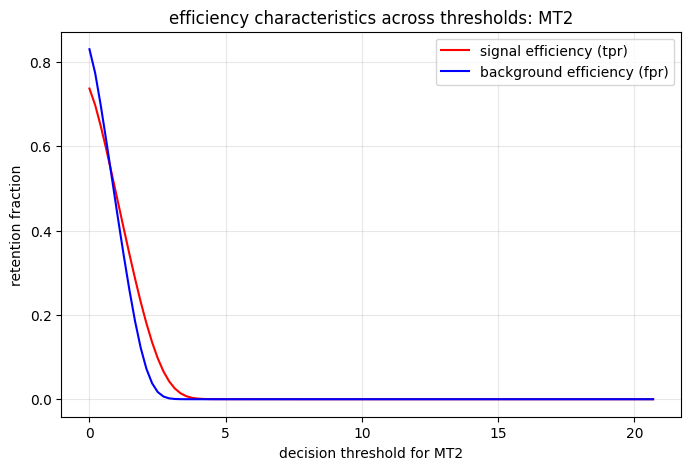

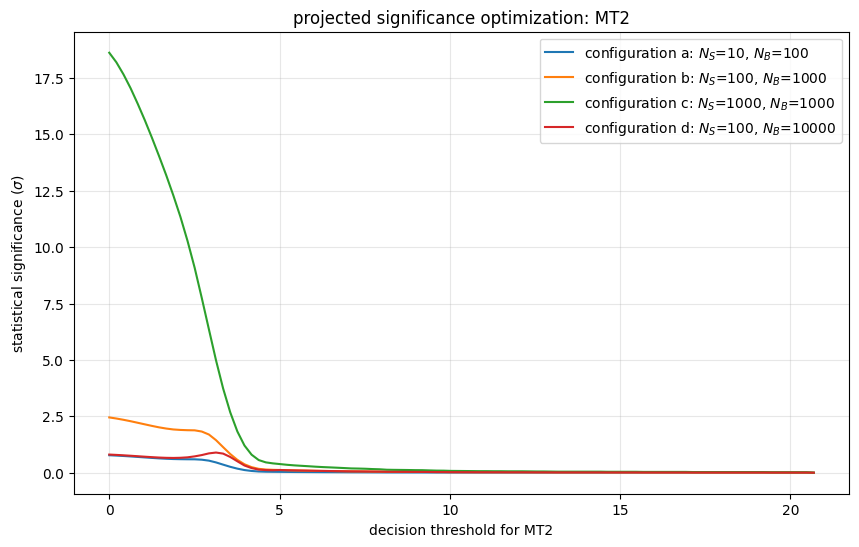

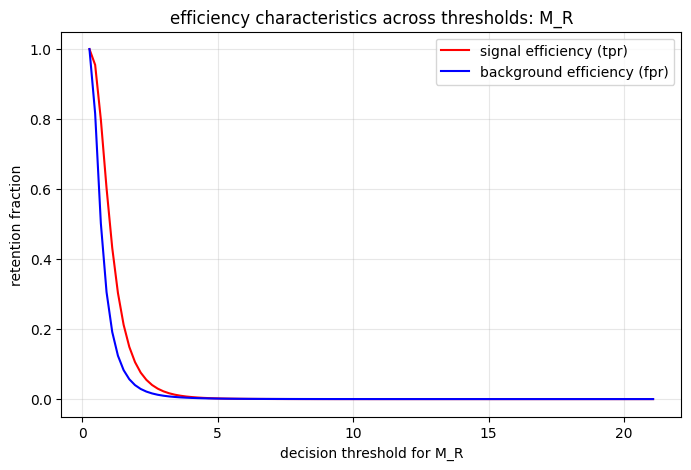

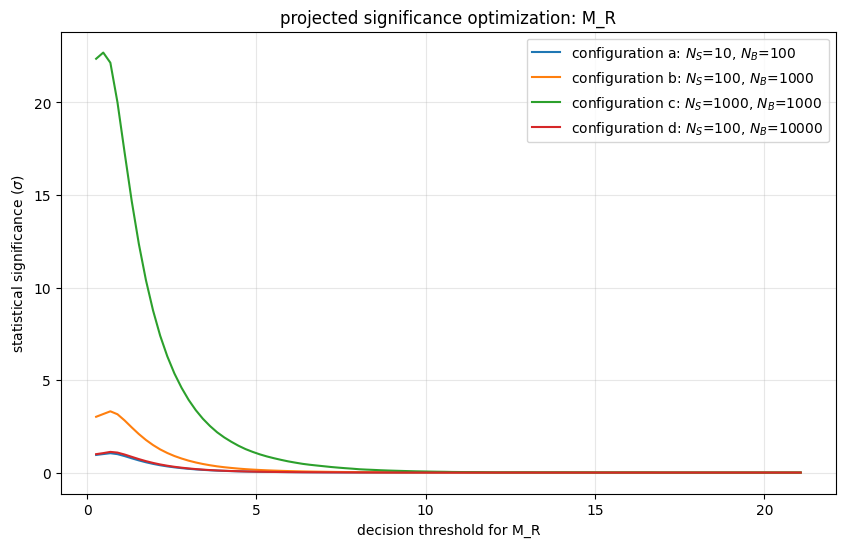

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def compute_efficiency_metrics(df, feature, resolution=100):
    # deduce the optimal threshold direction by evaluating class centroids.
    # if the signal mean exceeds the background mean, a right-sided topological cut is applied; otherwise, a left-sided cut.
    mu_signal = df[df.signal == 1.0][feature].mean()
    mu_background = df[df.signal == 0.0][feature].mean()

    # generate a linearly spaced sequence of potential cut thresholds spanning the feature's numerical domain.
    cut_thresholds = np.linspace(df[feature].min(), df[feature].max(), resolution)
    true_positive_rates = []
    false_positive_rates = []

    # isolate signal and background distributions into contiguous arrays to minimize computational overhead during iteration.
    signal_array = df[df.signal == 1.0][feature].values
    background_array = df[df.signal == 0.0][feature].values
    count_signal = len(signal_array)
    count_background = len(background_array)

    # systematically evaluate passing events across all threshold candidates.
    for threshold in cut_thresholds:
        if mu_signal > mu_background:
            # signal dominates the upper spectrum; isolate instances strictly greater than the designated threshold.
            true_positives = np.sum(signal_array > threshold)
            false_positives = np.sum(background_array > threshold)
        else:
            # signal dominates the lower spectrum; isolate instances strictly less than the designated threshold.
            true_positives = np.sum(signal_array < threshold)
            false_positives = np.sum(background_array < threshold)

        # normalize passing counts against the baseline integrals to compute fractional efficiencies.
        true_positive_rates.append(true_positives / count_signal if count_signal > 0 else 0)
        false_positive_rates.append(false_positives / count_background if count_background > 0 else 0)

    return cut_thresholds, np.array(true_positive_rates), np.array(false_positive_rates)


def visualize_efficiency_curves(df, feature):
    # renders a diagnostic plot detailing signal and background retention profiles as a function of the operational threshold.
    thresholds, tpr_array, fpr_array = compute_efficiency_metrics(df, feature)

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, tpr_array, color='red', label='signal efficiency (tpr)')
    plt.plot(thresholds, fpr_array, color='blue', label='background efficiency (fpr)')

    plt.xlabel(f"decision threshold for {feature}")
    plt.ylabel("retention fraction")
    plt.title(f"efficiency characteristics across thresholds: {feature}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def visualize_statistical_significance(df, feature, hypotheses):
    # computes and projects the statistical discovery significance under various theoretical background-to-signal yield assumptions.
    thresholds, tpr_array, fpr_array = compute_efficiency_metrics(df, feature)

    plt.figure(figsize=(10, 6))

    # iterate sequentially over the defined yield configurations.
    for yield_sig, yield_bkg, profile_label in hypotheses:
        # project the post-cut yields by modulating the baseline expectations via the empirically derived efficiencies.
        retained_signal = yield_sig * tpr_array
        retained_background = yield_bkg * fpr_array

        # approximate the statistical significance utilizing the standard discovery metric.
        # a negligible mathematical artifact (1e-10) is embedded in the denominator to circumvent zero-division anomalies.
        discovery_significance = retained_signal / np.sqrt(retained_signal + retained_background + 1e-10)

        plt.plot(thresholds, discovery_significance, label=f"{profile_label}: $N_S$={yield_sig}, $N_B$={yield_bkg}")

    plt.xlabel(f"decision threshold for {feature}")
    plt.ylabel(r"statistical significance ($\sigma$)")
    plt.title(f"projected significance optimization: {feature}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# define the baseline yield parameterizations for hypothesis testing.
yield_configurations = [
    (10, 100, "configuration a"),
    (100, 1000, "configuration b"),
    (1000, 1000, "configuration c"),
    (100, 10000, "configuration d")
]

# execute the analytical pipeline over the target kinematic observables.
# utilizing the 'df' variable which contains the loaded active dataframe.
for kinematic_var in ['MT2', 'M_R']:
    visualize_efficiency_curves(df, kinematic_var)
    visualize_statistical_significance(df, kinematic_var, yield_configurations)

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c).

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [32]:
import numpy as np
import tabulate
from IPython.display import HTML, display

def execute_sequential_cut_flow(dataset, selection_criteria, expected_signal_yield, expected_background_yield):
    # executes a sequential cut flow analysis based on a predefined set of topological criteria.

    # establish the initial unskimmed event counts to serve as the baseline for global efficiency calculations.
    total_initial_signal = len(dataset[dataset.signal == 1.0])
    total_initial_background = len(dataset[dataset.signal == 0.0])

    iteration_metrics = []

    # instantiate a working copy of the dataset to iteratively apply kinematic restrictions.
    working_dataset = dataset.copy()

    # iteratively apply each kinematic threshold to the working dataset.
    for index, (feature, threshold, operator) in enumerate(selection_criteria):

        # isolate the surviving subset based on the directional operator.
        if operator == '>':
            working_dataset = working_dataset[working_dataset[feature] > threshold]
        elif operator == '<':
            working_dataset = working_dataset[working_dataset[feature] < threshold]

        # evaluate the retention counts for the current selection stage.
        retained_signal = len(working_dataset[working_dataset.signal == 1.0])
        retained_background = len(working_dataset[working_dataset.signal == 0.0])

        # compute cumulative selection efficiencies relative to the unskimmed baseline.
        signal_efficiency = retained_signal / total_initial_signal if total_initial_signal > 0 else 0
        background_efficiency = retained_background / total_initial_background if total_initial_background > 0 else 0

        # purity represents the signal fraction within the currently retained phase space.
        total_retained = retained_signal + retained_background
        sample_purity = retained_signal / total_retained if total_retained > 0 else 0

        # scale the theoretical baseline yields by the cumulative selection efficiencies.
        projected_signal = expected_signal_yield * signal_efficiency
        projected_background = expected_background_yield * background_efficiency

        # compute the statistical discovery significance, embedding a computational safeguard against zero-division.
        discovery_significance = projected_signal / np.sqrt(projected_signal + projected_background + 1e-10)

        # record the computed metrics for the current application tier.
        iteration_metrics.append({
            'restriction': f"{feature} {operator} {threshold:.3f}",
            'yield_sig': retained_signal,
            'yield_bkg': retained_background,
            'eff_sig': signal_efficiency,
            'eff_bkg': background_efficiency,
            'purity': sample_purity,
            'proj_sig': projected_signal,
            'proj_bkg': projected_background,
            'significance': discovery_significance
        })

    # compile the iteration metrics into a structured format for the final rendering.
    compiled_rows = []
    for metric in iteration_metrics:
        compiled_rows.append([
            metric['restriction'],
            f"{metric['yield_sig']:.0f}",
            f"{metric['yield_bkg']:.0f}",
            f"{metric['eff_sig']:.3f}",
            f"{metric['eff_bkg']:.3f}",
            f"{metric['purity']:.3f}",
            f"{metric['proj_sig']:.1f}",
            f"{metric['proj_bkg']:.1f}",
            f"{metric['significance']:.2f}"
        ])

    # establish display headers and render the html matrix.
    matrix_headers = ['restriction', 'n_sig', 'n_bkg', 'eff_sig', 'eff_bkg', 'purity', 'proj_sig', 'proj_bkg', 'significance']
    display(HTML(tabulate.tabulate(compiled_rows, headers=matrix_headers, tablefmt='html', floatfmt=".3f")))

    return iteration_metrics

# initiate the diagnostic output for theoretical yield scenario two.
print("\n" + "="*80)
print("sequential restriction analysis - theoretical yields (S=100, B=1000)")
print("="*80)

# define the specific sequence of kinematic restrictions to be applied.
kinematic_restrictions = [
    ('MT2', 1.5, '>'),
    ('M_R', 1.0, '>'),
    ('MET_rel', 1.5, '>')
]

# execute the restriction pipeline over the active dataset.
execute_sequential_cut_flow(df, kinematic_restrictions, expected_signal_yield=100, expected_background_yield=1000)


sequential restriction analysis - theoretical yields (S=100, B=1000)


restriction,n_sig,n_bkg,eff_sig,eff_bkg,purity,proj_sig,proj_bkg,significance
MT2 > 1.500,765895,668326,0.335,0.246,0.534,33.500,246.400,2.000
M_R > 1.000,356269,137850,0.156,0.051,0.721,15.600,50.800,1.910
MET_rel > 1.500,227999,52108,0.100,0.019,0.814,10.000,19.200,1.840


[{'restriction': 'MT2 > 1.500',
  'yield_sig': 765895,
  'yield_bkg': 668326,
  'eff_sig': 0.3347696307456814,
  'eff_bkg': 0.24641717176596037,
  'purity': 0.5340146323335107,
  'proj_sig': 33.47696307456814,
  'proj_bkg': 246.41717176596038,
  'significance': np.float64(2.001009517479588)},
 {'restriction': 'M_R > 1.000',
  'yield_sig': 356269,
  'yield_bkg': 137850,
  'eff_sig': 0.15572375009124378,
  'eff_bkg': 0.05082640377291567,
  'purity': 0.7210186210204425,
  'proj_sig': 15.572375009124379,
  'proj_bkg': 50.82640377291567,
  'significance': np.float64(1.911062135707715)},
 {'restriction': 'MET_rel > 1.500',
  'yield_sig': 227999,
  'yield_bkg': 52108,
  'eff_sig': 0.09965744787521084,
  'eff_bkg': 0.019212638721792453,
  'purity': 0.8139710896193241,
  'proj_sig': 9.965744787521084,
  'proj_bkg': 19.21263872179245,
  'significance': np.float64(1.8449268316061223)}]

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



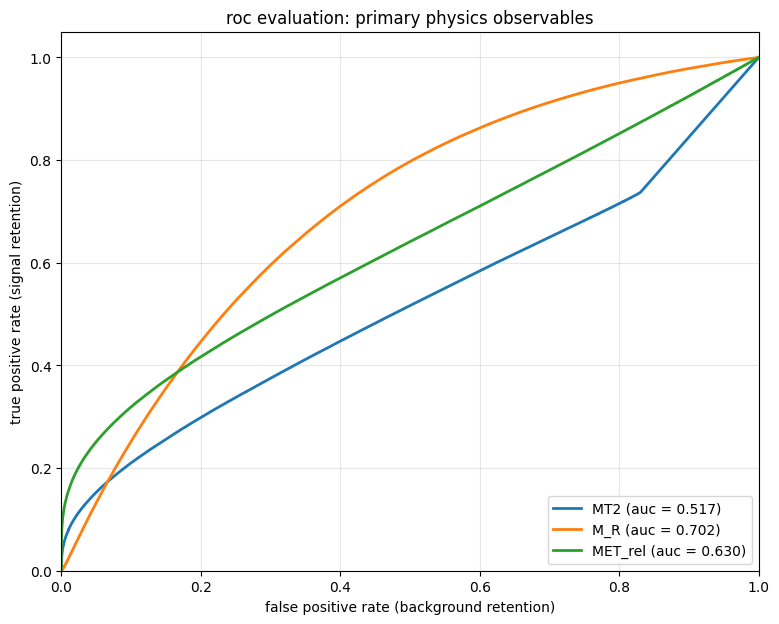

In [34]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def evaluate_roc_performance(dataset, features, plot_heading="receiver operating characteristic (roc) analysis"):
    # synthesizes comparative roc curves to evaluate the discriminative power of specified features.

    plt.figure(figsize=(9, 7))

    # iterate through the designated feature array to compute and plot individual performance trajectories.
    for feature in features:
        # compute the empirical false positive and true positive rates using the target array and feature distributions.
        false_pos_rate, true_pos_rate, _ = roc_curve(dataset['signal'], dataset[feature])

        # quantify the overall discriminatory performance via the area under the curve (auc).
        curve_area = auc(false_pos_rate, true_pos_rate)

        # correct for inverse correlations. if the initial auc falls below the random-guess threshold (0.5),
        # the feature topology implies a left-sided restriction. inverting the feature vector realigns the curve.
        if curve_area < 0.5:
            false_pos_rate, true_pos_rate, _ = roc_curve(dataset['signal'], -dataset[feature])
            curve_area = auc(false_pos_rate, true_pos_rate)

        # project the corrected coordinate pairs onto the current axes.
        plt.plot(false_pos_rate, true_pos_rate, lw=2, label=f'{feature} (auc = {curve_area:.3f})')

    # establish the non-informative baseline (random classification) as a visual reference.
    plt.plot(color='navy', lw=1, linestyle='--')

    # constrain axis boundaries and apply standard typographical formatting.
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('false positive rate (background retention)')
    plt.ylabel('true positive rate (signal retention)')
    plt.title(plot_heading)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# isolate the highest-performing kinematic observables for targeted evaluation.
primary_observables = ['MT2', 'M_R', 'MET_rel']

# execute the diagnostic visualization rendering.
evaluate_roc_performance(df, primary_observables, "roc evaluation: primary physics observables")

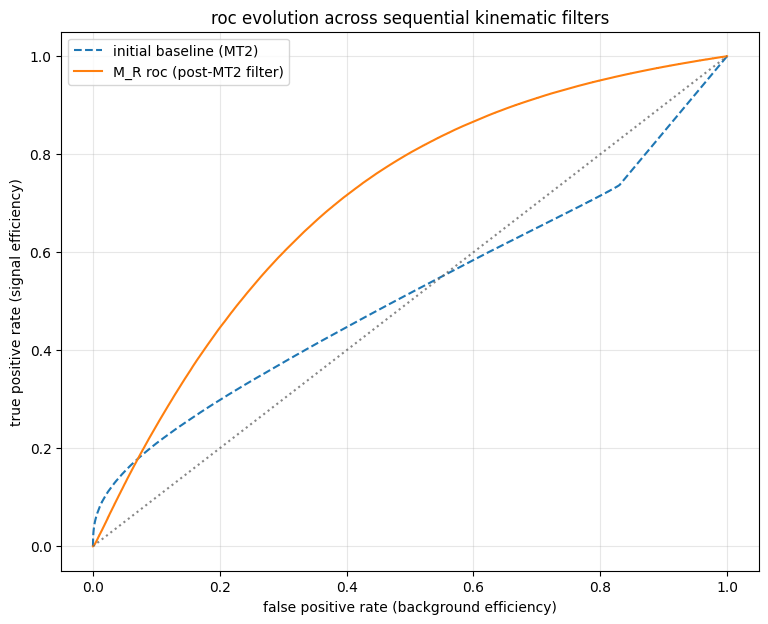

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

def evaluate_cascading_roc(dataset, threshold_sequence):
    # duplicate the source dataframe to safely apply sequential masking operations.
    active_data = dataset.copy()
    plt.figure(figsize=(9, 7))

    # compute and plot the unmasked baseline roc for the primary predictive feature.
    # extraction index isolates the string identifier from the nested tuple structure.
    base_feature = threshold_sequence[0][0]
    fpr_base, tpr_base, _ = roc_curve(active_data['signal'], active_data[base_feature])
    plt.plot(fpr_base, tpr_base, label=f'initial baseline ({base_feature})', linestyle='--')

    # iterate through the sequence of kinematic thresholds to isolate the target phase space.
    for step_index, (feature, threshold, operator) in enumerate(threshold_sequence):

        # apply directional masking based on the specified operator constraint.
        if operator == '>':
            active_data = active_data[active_data[feature] > threshold]
        else:
            active_data = active_data[active_data[feature] < threshold]

        # evaluate the discriminative capacity of the subsequent feature strictly on the surviving dataset.
        if step_index + 1 < len(threshold_sequence):
            # extraction index isolates the string identifier for the subsequent feature variable.
            next_feature = threshold_sequence[step_index + 1][0]

            # verify the surviving dataset is not completely empty before calculating the roc curve.
            if len(active_data) > 0:
                fpr_sub, tpr_sub, _ = roc_curve(active_data['signal'], active_data[next_feature])
                plt.plot(fpr_sub, tpr_sub, label=f'{next_feature} roc (post-{feature} filter)')
            else:
                print(f"warning: the restriction on {feature} eliminated all remaining events.")

    # overlay the theoretical random-chance baseline matrix coordinates.
    # explicitly defines the coordinate vectors to resolve the syntax error.
    plt.plot([0, 1], [0, 1], color='dimgray', linestyle=':', alpha=0.8)

    # apply standardized visualization typography and axis formatting.
    plt.title("roc evolution across sequential kinematic filters")
    plt.xlabel("false positive rate (background efficiency)")
    plt.ylabel("true positive rate (signal efficiency)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# define the cascade of selection cuts applied to the physics observables.
kinematic_filters = [
    ('MT2', 1.0, '>'),
    ('M_R', 0.8, '>')
]

# execute the sequential evaluation on the primary dataframe.
evaluate_cascading_roc(df, kinematic_filters)

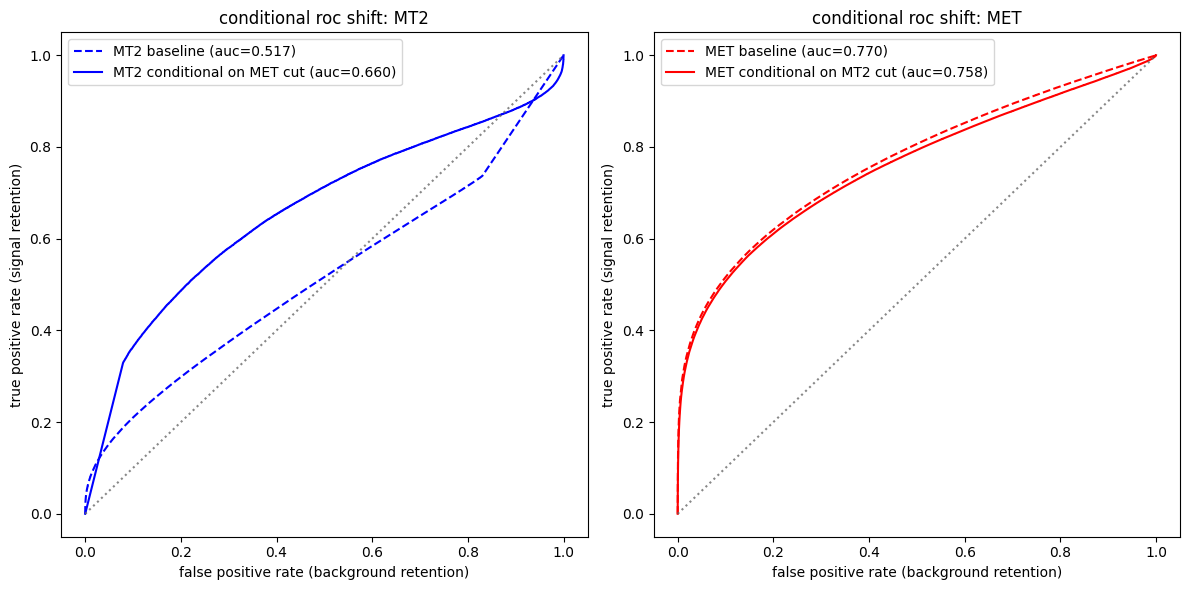

In [47]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def compute_roc_metrics(dataset, feature):
    # computes empirical roc coordinates and integrates the area under the curve.
    false_pos_rate, true_pos_rate, _ = roc_curve(dataset['signal'], dataset[feature])
    curve_area = auc(false_pos_rate, true_pos_rate)

    # corrects for inverse phase space mapping by inverting the feature array if the area falls below random chance.
    if curve_area < 0.5:
        false_pos_rate, true_pos_rate, _ = roc_curve(dataset['signal'], -dataset[feature])
        curve_area = auc(false_pos_rate, true_pos_rate)

    return false_pos_rate, true_pos_rate, curve_area

# isolate two highly correlated physics observables to evaluate orthogonal restriction impacts.
primary_feature = 'MT2'
secondary_feature = 'MET'

# evaluate the unskimmed discriminative capacity for both features independently.
fpr_primary_base, tpr_primary_base, auc_primary_base = compute_roc_metrics(df, primary_feature)
fpr_secondary_base, tpr_secondary_base, auc_secondary_base = compute_roc_metrics(df, secondary_feature)

# scenario a: evaluate the primary feature strictly within the phase space surviving a secondary feature restriction.
dataset_post_secondary_filter = df[df[secondary_feature] > 1.5]
fpr_primary_conditional, tpr_primary_conditional, auc_primary_conditional = compute_roc_metrics(dataset_post_secondary_filter, primary_feature)

# scenario b: evaluate the secondary feature strictly within the phase space surviving a primary feature restriction.
dataset_post_primary_filter = df[df[primary_feature] > 1.5]
fpr_secondary_conditional, tpr_secondary_conditional, auc_secondary_conditional = compute_roc_metrics(dataset_post_primary_filter, secondary_feature)

# instantiate a dual-panel visualization matrix to project the comparative performance degradation.
plt.figure(figsize=(12, 6))

# render the primary feature performance shift in the left subplot.
plt.subplot(1, 2, 1)
plt.plot(fpr_primary_base, tpr_primary_base, 'b--', label=f'{primary_feature} baseline (auc={auc_primary_base:.3f})')
plt.plot(fpr_primary_conditional, tpr_primary_conditional, 'b-', label=f'{primary_feature} conditional on {secondary_feature} cut (auc={auc_primary_conditional:.3f})')
plt.plot([0, 1], [0, 1], color='dimgray', linestyle=':', alpha=0.8)

plt.title(f"conditional roc shift: {primary_feature}")
plt.xlabel("false positive rate (background retention)")
plt.ylabel("true positive rate (signal retention)")
plt.legend()

# render the secondary feature performance shift in the right subplot.
plt.subplot(1, 2, 2)
plt.plot(fpr_secondary_base, tpr_secondary_base, 'r--', label=f'{secondary_feature} baseline (auc={auc_secondary_base:.3f})')
plt.plot(fpr_secondary_conditional, tpr_secondary_conditional, 'r-', label=f'{secondary_feature} conditional on {primary_feature} cut (auc={auc_secondary_conditional:.3f})')
plt.plot([0, 1], [0, 1], color='dimgray', linestyle=':', alpha=0.8)

plt.title(f"conditional roc shift: {secondary_feature}")
plt.xlabel("false positive rate (background retention)")
plt.ylabel("true positive rate (signal retention)")
plt.legend()

# apply layout optimization to prevent typography overlap across the subplot matrix.
plt.tight_layout()
plt.show()

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$.

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5?

In [48]:
import numpy as np

# aggregate the primary and derived kinematic observables into a unified feature space.
combined_observables = RawNames + FeatureNames

# partition the dataset into distinct signal and background topological matrices.
signal_matrix = df[df.signal == 1.0][combined_observables].values
background_matrix = df[df.signal == 0.0][combined_observables].values

# calculate the empirical centroid vectors for both the signal and background distributions.
mu_signal = np.mean(signal_matrix, axis=0)
mu_background = np.mean(background_matrix, axis=0)

# construct the within-class scatter matrix by aggregating the individual class covariances.
# the transpose operation aligns the observational axes properly for standard numpy covariance execution.
scatter_within = np.cov(signal_matrix.T) + np.cov(background_matrix.T)

# formulate the between-class scatter matrix utilizing the outer product of the centroid differential.
centroid_differential = (mu_background - mu_signal).reshape(-1, 1)
scatter_between = centroid_differential @ centroid_differential.T

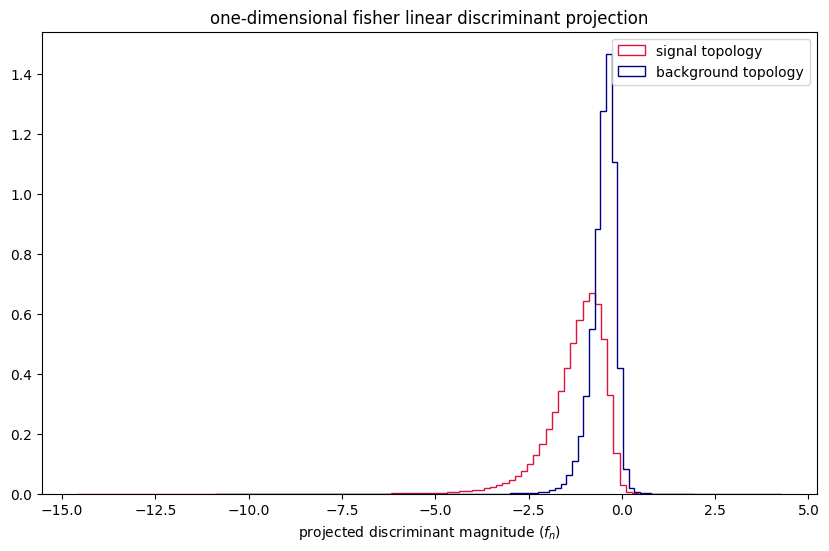

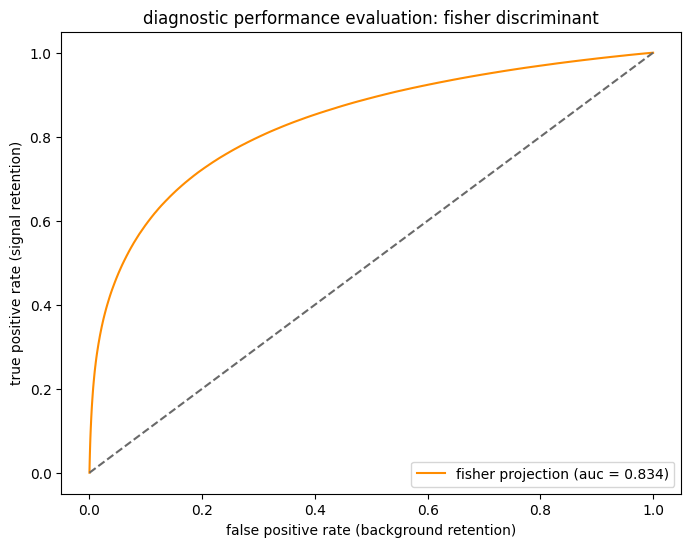

optimal discovery significance for theoretical configuration four: 2.22 sigma


In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# define the fundamental kinematic vectors and the synthesized high-level physics observables.
primary_kinematics = ["l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
derived_observables = ["axial_MET", "MET_rel", "M_R", "cos_theta_r1", "MT2",
                       "dPhi_r_b", "M_TR_2", "R", "S_R", "M_Delta_R"]

# aggregate all variables to construct the complete n-dimensional feature space.
complete_feature_space = primary_kinematics + derived_observables

# partition the phase space into isolated signal and background observation matrices.
matrix_signal = df[df.signal == 1.0][complete_feature_space].values
matrix_background = df[df.signal == 0.0][complete_feature_space].values

# evaluate the empirical centroid vectors across all dimensions for both topological classes.
centroid_signal = np.mean(matrix_signal, axis=0)
centroid_background = np.mean(matrix_background, axis=0)

# construct the within-class scatter matrix by summing the independent class covariance matrices.
scatter_within = np.cov(matrix_signal.T) + np.cov(matrix_background.T)

# derive the optimal fisher projection weights.
# utilizing linear algebraic resolution (solve) rather than direct matrix inversion mitigates floating-point instability.
fisher_weights = np.linalg.solve(scatter_within, (centroid_background - centroid_signal))

# map the high-dimensional dataset onto the one-dimensional fisher discriminant axis via dot product.
df['fisher_discriminant'] = df[complete_feature_space].values @ fisher_weights

# render the resultant probability density distributions for the projected phase space.
plt.figure(figsize=(10, 6))
plt.hist(df[df.signal == 1.0]['fisher_discriminant'], bins=100, color='crimson',
         histtype='step', label='signal topology', density=True)
plt.hist(df[df.signal == 0.0]['fisher_discriminant'], bins=100, color='navy',
         histtype='step', label='background topology', density=True)
plt.title("one-dimensional fisher linear discriminant projection")
plt.xlabel("projected discriminant magnitude ($f_n$)")
plt.legend()
plt.show()

# compute the empirical receiver operating characteristic metrics for the novel fisher projection.
false_pos_rate, true_pos_rate, _ = roc_curve(df['signal'], df['fisher_discriminant'])
curve_area = auc(false_pos_rate, true_pos_rate)

# dynamically invert the phase space mapping if the resultant area indicates an inverse correlation anomaly.
if curve_area < 0.5:
    false_pos_rate, true_pos_rate, _ = roc_curve(df['signal'], -df['fisher_discriminant'])
    curve_area = auc(false_pos_rate, true_pos_rate)

# project the diagnostic performance curve.
plt.figure(figsize=(8, 6))
plt.plot(false_pos_rate, true_pos_rate, color='darkorange', label=f'fisher projection (auc = {curve_area:.3f})')
plt.plot([0, 1], [0, 1], color='dimgray', linestyle='--')
plt.xlabel('false positive rate (background retention)')
plt.ylabel('true positive rate (signal retention)')
plt.title('diagnostic performance evaluation: fisher discriminant')
plt.legend(loc="lower right")
plt.show()

# execute a statistical significance optimization sweep for theoretical yield configuration four.
# this utilizes the efficiency metrics pipeline established in prior execution cells.
cut_thresholds, signal_eff_array, bkg_eff_array = compute_efficiency_metrics(df, 'fisher_discriminant')

# scale the expected baseline yields against the empirically derived retention rates.
projected_signal_yield = 100 * signal_eff_array
projected_background_yield = 10000 * bkg_eff_array

# approximate the discovery significance, utilizing a fractional artifact to bypass zero-division limits.
discovery_significance = projected_signal_yield / np.sqrt(projected_signal_yield + projected_background_yield + 1e-10)

# extract and output the absolute maximum significance achievable within the projection.
print(f"optimal discovery significance for theoretical configuration four: {np.max(discovery_significance):.2f} sigma")